In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
import yfinance as yf

In [5]:
start_date = '2019-01-01'
end_date = '2025-12-31'
dat = yf.download('JPM', start = start_date, end = end_date, interval = '1d')

[*********************100%***********************]  1 of 1 completed


In [6]:
dat['Close']

Ticker,JPM
Date,
2019-01-02,81.250206
2019-01-03,80.095512
2019-01-04,83.048271
2019-01-07,83.105988
2019-01-08,82.949280
...,...
2025-12-23,324.466400
2025-12-24,327.691864
2025-12-26,326.437531


In [7]:
dat['r'] = dat['Close'] / dat['Close'].shift(1)
dat['log-r'] = np.log(dat['r'])
dat = dat.dropna()

In [8]:
dat['log-r']

Date
2019-01-03   -0.014314
2019-01-04    0.036202
2019-01-07    0.000695
2019-01-08   -0.001887
2019-01-09   -0.001692
                ...   
2025-12-23    0.008752
2025-12-24    0.009892
2025-12-26   -0.003835
2025-12-29   -0.012768
2025-12-30   -0.001020
Name: log-r, Length: 1758, dtype: float64

In [9]:
dat.to_csv('JPM_return.csv', index=True)

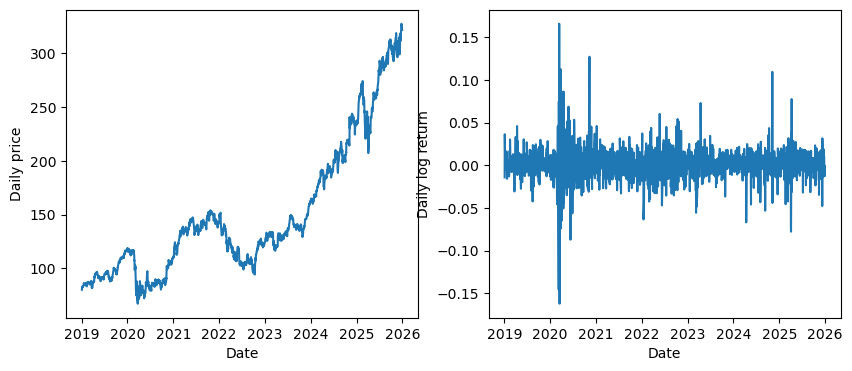

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(dat['Close'])
ax[1].plot(dat['log-r'])
for i in range(2):
    ax[i].set_xlabel('Date')
ax[0].set_ylabel('Daily price')
ax[1].set_ylabel('Daily log return');

In [11]:
print(f"mean: {dat['log-r'].mean():.3f}") # mean

mean: 0.001


In [12]:
print(f"std: {dat['log-r'].std():.3f}") # std

std: 0.019


In [13]:
print(f"skewness: {dat['log-r'].skew():.3f}") # skewness

skewness: -0.080


In [14]:
print(f"kurtosis: {dat['log-r'].kurtosis() + 3:.3f}") # kurtosis = excess kurtosis + 3

kurtosis: 16.244


In [15]:
print(f"annualized mean return: {dat['log-r'].mean() * 252:.3f}") # annualized return 

annualized mean return: 0.197


In [16]:
print(f"annualized volatility: {dat['log-r'].std() * 252 ** 0.5:.3f}") # annualized volatility

annualized volatility: 0.298


In [17]:
dat = dat['log-r']

In [18]:
from scipy import stats

In [19]:
mu, sigma = stats.norm.fit(dat)
print(mu, sigma)

0.0007832297565195089 0.01879804938092263


In [20]:
import statsmodels.api as sm

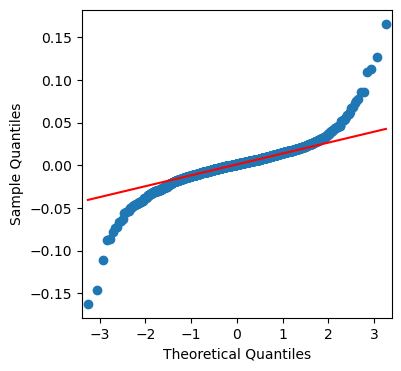

In [21]:
fig, ax=plt.subplots(figsize=(4,4))
sm.qqplot(data=dat, dist=stats.norm, line='q', ax=ax);

In [22]:
# Jarque-Bera test
stats.jarque_bera(dat) 

Jarque_beraResult(statistic=12771.042012568281, pvalue=0.0)

In [23]:
# Shapiro-Wilk test
stats.shapiro(dat) 

ShapiroResult(statistic=0.8776119351387024, pvalue=4.2634474118947653e-35)

P-value is around 0.0, thus the daily return can not fit in lognormal distribution.

In [24]:
df, loc, scale = stats.t.fit(dat) # t-distribution
print(df, loc, scale)

2.901629025545959 0.0011353779187712983 0.01104183188839328


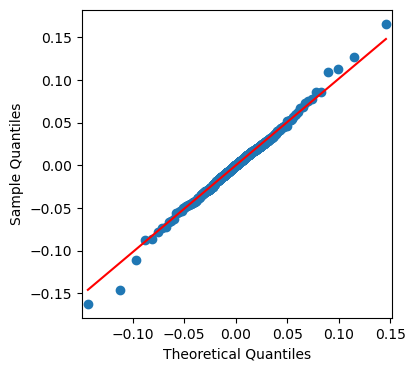

In [25]:
fig, ax=plt.subplots(figsize=(4,4))
sm.qqplot(data=dat, dist=stats.t(df=df, loc=loc, scale=scale), line='q', ax=ax);

In [26]:
# Jarque-Bera test
stats.jarque_bera(dat) 

Jarque_beraResult(statistic=12771.042012568281, pvalue=0.0)

In [27]:
# Shapiro-Wilk test
stats.shapiro(dat) 

ShapiroResult(statistic=0.8776119351387024, pvalue=4.2634474118947653e-35)

We can clearly observe a good alignment between the sample quantiles and theoretical quantiles in t-distribution.

In [28]:
S0 = 1000
days = 252
sim = 10000

annual_log_r = []
for _ in range(sim):
    daily_r = stats.t.rvs(df=df, loc=loc, scale=scale, size=days) 
    # Sample 252 daily log returns from the distribution
    annual_log_r.append(daily_r.sum()) 
    # Add them up to get one observation for the annual log return.
PnL = S0 * (np.exp(annual_log_r) - 1)

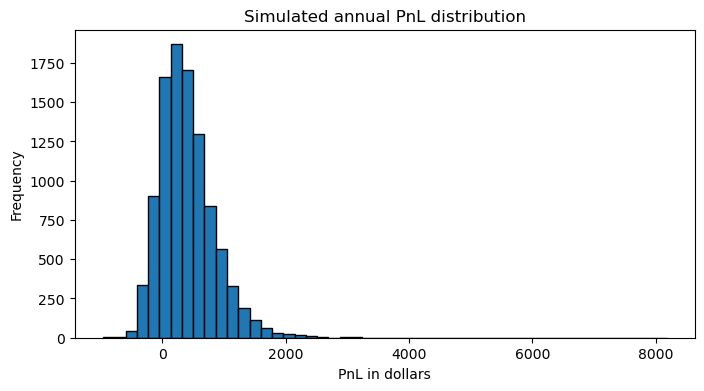

In [29]:
plt.figure(figsize=(8,4))
plt.hist(PnL, bins=50,edgecolor='k')
plt.title('Simulated annual PnL distribution')
plt.xlabel('PnL in dollars')
plt.ylabel('Frequency')
plt.show()

In [30]:
print(f"mean: {PnL.mean():.3f}") # mean

mean: 397.260


In [31]:
print(f"std: {PnL.std():.3f}") # std

std: 457.027


In [32]:
print(f"VaR: {np.quantile(PnL, 0.05):.3f}") # 5% quantile

VaR: -202.022
